<a href="https://colab.research.google.com/github/KamoTaueatsoala/ML-Projects/blob/main/Irrigation_Schedule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Sample Data:
   temperature   humidity  soil_moisture  dry  pump  water_quantity  \
0    27.490142  46.710050     563.548292    0     0      306.261225   
1    25.585207  49.398190     311.675201    1     1      680.333059   
2    27.943066  62.472936     580.440888    0     0      306.114875   
3    30.569090  61.103703     653.345679    0     0      327.164901   
4    25.297540  54.790984     512.015235    0     0      302.443004   

   temp_moist_interaction  
0            15492.022843  
1             7974.274574  
2            16219.297819  
3            19972.182576  
4            12952.725837  

🔍 Best KNN Params: {'n_neighbors': 9}
🔍 KNN Accuracy: 0.967
📑 KNN Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.94      0.94      0.94        18

    accuracy                           0.97        60
   macro avg       0.96      0.96      0.96        60
weighted avg       0.97    

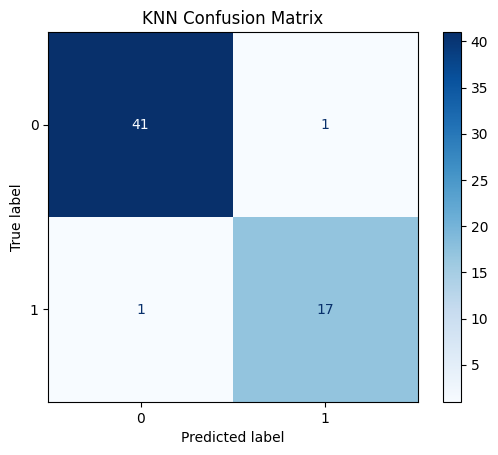

📊 KNN CV Accuracy (mean ± std): 0.971 ± 0.025

📈 Naive Bayes Accuracy: 0.883
📑 Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.88      0.91        42
           1       0.76      0.89      0.82        18

    accuracy                           0.88        60
   macro avg       0.86      0.88      0.87        60
weighted avg       0.89      0.88      0.89        60



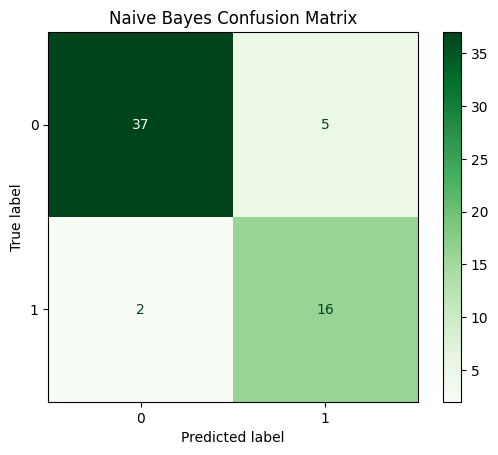

📊 Naive Bayes CV Accuracy (mean ± std): 0.950 ± 0.052

🌲 Best Random Forest Params: {'max_depth': 3, 'n_estimators': 150}
💧 Water Quantity Prediction MSE: 2794.08
💧 Water Quantity Prediction R²: 0.909
💧 Water Quantity Prediction MAE: 42.56


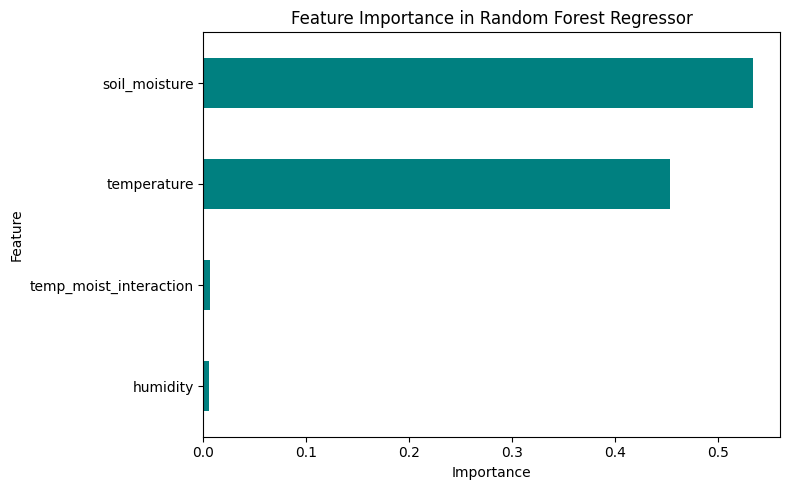

<ipython-input-81-7d34b110e249>:142: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=y_test_water, y=y_pred_water, palette='viridis', s=60, alpha=0.7)
<ipython-input-81-7d34b110e249>:153: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


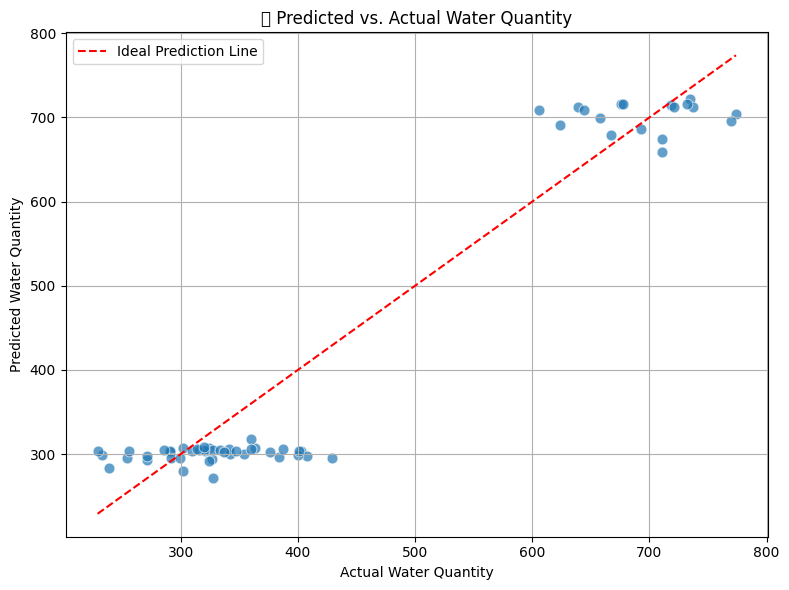

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    mean_squared_error, r2_score, mean_absolute_error,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestRegressor

# 🔁 Step 1: Simulate realistic sensor data with fixed random seed for reproducibility
def simulate_realistic_sensor_data(n_samples=300, random_state=42):
    np.random.seed(random_state)
    temperature = np.random.normal(26, 3, n_samples)
    humidity = np.random.normal(55, 10, n_samples)
    soil_moisture = np.random.normal(450, 150, n_samples)

    temperature = np.clip(temperature, 20, 35)
    humidity = np.clip(humidity, 30, 80)
    soil_moisture = np.clip(soil_moisture, 200, 800)

    # Define dry condition and pump usage logic
    dry = ((soil_moisture < 400) & (temperature > 25)).astype(int)
    pump = dry  # 1 = on, 0 = off

    water_quantity = np.where(
        dry == 1,
        np.random.normal(700, 50, n_samples),
        np.random.normal(300, 50, n_samples)
    )

    df = pd.DataFrame({
        'temperature': temperature,
        'humidity': humidity,
        'soil_moisture': soil_moisture,
        'dry': dry,
        'pump': pump,
        'water_quantity': water_quantity
    })

    df['temp_moist_interaction'] = df['temperature'] * df['soil_moisture']
    return df

# 📊 Step 2: Generate and inspect dataset
df = simulate_realistic_sensor_data()
print("✅ Sample Data:")
print(df.head())

# 🎯 Step 3: Define features and targets
features = ['temperature', 'humidity', 'soil_moisture', 'temp_moist_interaction']
X = df[features]
y_dry = df['dry']
y_water = df['water_quantity']

# 📦 Step 4: Split dataset (fix random_state for reproducibility)
X_train, X_test, y_train_dry, y_test_dry, y_train_water, y_test_water = train_test_split(
    X, y_dry, y_water, test_size=0.2, random_state=42
)

# 🧪 Step 5: Standardize features for classification tasks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🤖 Step 6: KNN Classifier with Grid Search
param_grid_knn = {'n_neighbors': list(range(1, 11))}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5)
grid_knn.fit(X_train_scaled, y_train_dry)
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)

print(f"\n🔍 Best KNN Params: {grid_knn.best_params_}")
print(f"🔍 KNN Accuracy: {accuracy_score(y_test_dry, y_pred_knn):.3f}")
print("📑 KNN Classification Report:\n", classification_report(y_test_dry, y_pred_knn))

# Confusion matrix for KNN
cm_knn = confusion_matrix(y_test_dry, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot(cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.show()

# ⛓️ KNN Cross-validation accuracy
cv_scores_knn = cross_val_score(best_knn, X_train_scaled, y_train_dry, cv=5)
print(f"📊 KNN CV Accuracy (mean ± std): {np.mean(cv_scores_knn):.3f} ± {np.std(cv_scores_knn):.3f}")

# 📬 Step 7: Naive Bayes Classifier
nb = GaussianNB()
nb.fit(X_train_scaled, y_train_dry)
y_pred_nb = nb.predict(X_test_scaled)

print(f"\n📈 Naive Bayes Accuracy: {accuracy_score(y_test_dry, y_pred_nb):.3f}")
print("📑 Naive Bayes Classification Report:\n", classification_report(y_test_dry, y_pred_nb))

# Confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_test_dry, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_nb.plot(cmap='Greens')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

cv_scores_nb = cross_val_score(nb, X_train_scaled, y_train_dry, cv=5)
print(f"📊 Naive Bayes CV Accuracy (mean ± std): {np.mean(cv_scores_nb):.3f} ± {np.std(cv_scores_nb):.3f}")

# 🌲 Step 8: Random Forest Regressor with Grid Search (no scaling needed)
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 10, None]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train_water)
best_rf = grid_rf.best_estimator_
y_pred_water = best_rf.predict(X_test)

# 📏 Regression Metrics
mse = mean_squared_error(y_test_water, y_pred_water)
r2 = r2_score(y_test_water, y_pred_water)
mae = mean_absolute_error(y_test_water, y_pred_water)

print(f"\n🌲 Best Random Forest Params: {grid_rf.best_params_}")
print(f"💧 Water Quantity Prediction MSE: {mse:.2f}")
print(f"💧 Water Quantity Prediction R²: {r2:.3f}")
print(f"💧 Water Quantity Prediction MAE: {mae:.2f}")

# Feature importance plot for Random Forest Regressor
feat_importances = pd.Series(best_rf.feature_importances_, index=features)
plt.figure(figsize=(8,5))
feat_importances.sort_values().plot(kind='barh', color='teal')
plt.title("Feature Importance in Random Forest Regressor")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 🧿 Step 9: Plot Predictions vs Actual for regression
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_water, y=y_pred_water, palette='viridis', s=60, alpha=0.7)
plt.plot(
    [y_test_water.min(), y_test_water.max()],
    [y_test_water.min(), y_test_water.max()],
    color='red', linestyle='--', label='Ideal Prediction Line'
)
plt.xlabel("Actual Water Quantity")
plt.ylabel("Predicted Water Quantity")
plt.title("🔮 Predicted vs. Actual Water Quantity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
